<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

<b>Comentário geral:</b> Murilo, parabéns, **projeto APROVADO!** E preciso dizer: você entregou muito mais do que a etapa pedia. O que era para ser uma decomposição virou uma **análise completa e executada** da CallMeMaybe, com 92 células, quatro hipóteses testadas e até um dashboard publicado.

Destaco cinco coisas que fogem do comum:

<ul class='text-success'><li>Você criou a métrica de tempo de espera, **validou**, encontrou valores extremos e então **corrigiu a própria interpretação da métrica**. Voltar atrás quando o dado contradiz a suposição é raro e valioso.</li><li>Validou o cálculo de chamadas perdidas **por um segundo método**, para confirmar o primeiro.</li><li>Definiu os limiares de ineficiência por **percentil**, a partir da própria distribuição, e não com números escolhidos a esmo.</li><li>Testou **quatro hipóteses** (H1 a H4), incluindo uma sobre a relação entre plano tarifário e proporção de operadores ineficientes.</li><li>E ainda refatorou o código em uma função reutilizável no final.</li></ul>

O dashboard no Tableau Public também está no ar (testei o link). Excelente trabalho!
</div>

<div style="background-color:#e8f4ea; padding:12px; border-left:5px solid #2e7d32;">

# 🧹 Fase 1 — Pré-processamento de Dados

Nesta fase, preparei os dados brutos para análise: carregamento, checagem de
qualidade (nulos, duplicatas, tipos), tratamento criterioso de valores ausentes,
união das duas bases fornecidas e criação de métricas derivadas necessárias
(tempo de espera).

</div>

In [1]:

import pandas as pd

calls = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [2]:
# Visão geral rápida de cada dataset: dimensões e primeiras linhas
# Usei o Display, pois a formatação é mais limpa e melhor de vizualizar.

print("calls - shape:", calls.shape)
display(calls.head())

print("clients - shape:", clients.shape)
display(clients.head())

calls - shape: (53902, 9)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


clients - shape: (732, 3)


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [3]:
# Verificaçaõ de nulos, duplicadas e tipo de dados.
# agrupados as verificações em um só loop.
for name, df in [('calls', calls), ('clients', clients)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print("\nNulos por coluna:")
    print(df.isnull().sum())
    print("\nLinhas duplicadas:", df.duplicated().sum())
    print()

--- calls ---
user_id                  int64
date                    object
direction               object
internal                object
operator_id            float64
is_missed_call            bool
calls_count              int64
call_duration            int64
total_call_duration      int64
dtype: object

Nulos por coluna:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Linhas duplicadas: 4900

--- clients ---
user_id         int64
tariff_plan    object
date_start     object
dtype: object

Nulos por coluna:
user_id        0
tariff_plan    0
date_start     0
dtype: int64

Linhas duplicadas: 0



In [4]:
# Olhando algumas linhas duplicadas de perto antes de decidir removê-las
duplicadas = calls[calls.duplicated(keep=False)]
duplicadas.sort_values(by=['user_id', 'date', 'operator_id']).head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
43,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
38,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
46,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473


### Tratamento de linhas duplicadas

Ao investigar as 4.900 linhas duplicadas encontradas em `calls`, observamos que:

- As duplicatas aparecem sempre em **pares** (nunca em grupos maiores).
- Os valores são **idênticos em todas as colunas**, incluindo métricas já agregadas
  (`calls_count`, `call_duration`, `total_call_duration`).
- A granularidade da tabela é "por operador, por dia, por direção de chamada" — ou seja,
  cada linha já representa uma agregação diária. Não há justificativa de negócio para que
  o mesmo operador tenha duas linhas agregadas idênticas para o mesmo dia e direção.

Isso indica que as duplicatas são um **artefato do processo de exportação/geração dos dados**,
e não informações legítimas distintas. Por isso, vamos removê-las, mantendo a contagem
de linhas antes/depois documentada para rastreabilidade.

In [5]:
linhas_antes = calls.shape[0]

calls = calls.drop_duplicates().reset_index(drop=True)

linhas_depois = calls.shape[0]
print(f"Linhas antes: {linhas_antes}")
print(f"Linhas depois: {linhas_depois}")
print(f"Linhas removidas: {linhas_antes - linhas_depois}")

Linhas antes: 53902
Linhas depois: 49002
Linhas removidas: 4900


In [6]:
# Convertendo 'date' para datetime
calls['date'] = pd.to_datetime(calls['date'])

# Confirmando a conversão
print(calls['date'].dtype)
print(calls['date'].min(), "até", calls['date'].max())

datetime64[ns, pytz.FixedOffset(180)]
2019-08-02 00:00:00+03:00 até 2019-11-28 00:00:00+03:00


In [7]:
# Convertendo date_start também para datetime
clients['date_start'] = pd.to_datetime(clients['date_start'])

print(clients['date_start'].dtype)
print(clients['date_start'].min(), "até", clients['date_start'].max())

datetime64[ns]
2019-08-01 00:00:00 até 2019-10-31 00:00:00


### Padronização de timezone

A coluna `date` (em `calls`) veio com timezone (`+03:00`), enquanto `date_start`
(em `clients`) veio sem timezone. Para permitir comparações e merges diretos entre
as duas tabelas, é necessário que ambas estejam no mesmo formato.

Optei por remover o timezone de `date`, e não adicionar em `date_start`, pois esta
análise trabalha em granularidade **diária** — o fuso horário específico não é
relevante para os agrupamentos e comparações que faremos. Essa é uma decisão de
modelagem, não apenas técnica.

In [8]:
# Removendo timezone de 'date' para ficar consistente com 'date_start'
calls['date'] = calls['date'].dt.tz_localize(None)

print(calls['date'].dtype)

datetime64[ns]


### Unindo os dados de chamadas com os dados de clientes

Realizei o merge de `calls` com `clients` usando `user_id` como chave, com `how='left'`
para preservar todas as chamadas mesmo que, por algum motivo, o cliente correspondente
não apareça em `clients` (órfãos). Verificamos essa possibilidade checando quantos
`user_id` ficaram sem `tariff_plan` após o merge — isso indicaria inconsistência entre
as duas bases fornecidas.

In [9]:
# Unindo as informações de plano tarifário e data de início de cada cliente
df = calls.merge(clients, on='user_id', how='left')

print("Shape após merge:", df.shape)
print("user_id em calls sem correspondência em clients:", df['tariff_plan'].isnull().sum())

Shape após merge: (49002, 11)
user_id em calls sem correspondência em clients: 0


O merge não gerou nenhum registro órfão (`user_id` em `calls` sem correspondência em
`clients`), confirmando consistência estrutural entre as duas bases fornecidas.
O DataFrame resultante `df` possui 49.002 linhas e 11 colunas, e será a partir de
agora nossa base de trabalho unificada.

In [10]:
# Verificando as linhas onde 'internal' é nulo, antes de decidir o tratamento
df[df['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
917,166405,2019-09-18,in,NaN,NaN,True,1,0,59,B,2019-08-02
996,166405,2019-10-01,in,NaN,NaN,True,1,0,1,B,2019-08-02
1705,166406,2019-08-20,in,NaN,NaN,True,1,0,36,B,2019-08-02
1761,166406,2019-09-02,in,NaN,879898.0,False,1,2,9,B,2019-08-02
5645,166541,2019-09-26,in,NaN,908960.0,False,1,393,423,A,2019-08-07
...,...,...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09,in,NaN,NaN,True,6,0,14,A,2019-10-23
47819,168361,2019-11-13,in,NaN,NaN,True,2,0,6,A,2019-10-23
47844,168361,2019-11-14,in,NaN,NaN,True,1,0,2,A,2019-10-23
48837,168579,2019-11-09,in,NaN,NaN,True,1,0,18,B,2019-10-31


In [11]:
# Confirmando se o padrão se repete em todas as linhas com 'internal' nulo
nulos_internal = df[df['internal'].isnull()]
print(nulos_internal['direction'].value_counts())

in     108
out      2
Name: direction, dtype: int64


In [12]:
# Olhando de perto os 2 casos que fogem do padrão
nulos_internal[nulos_internal['direction'] == 'out']

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
19099,167016,2019-10-23,out,NaN,NaN,True,3,0,196,C,2019-08-28
46717,168291,2019-11-28,out,NaN,NaN,True,3,0,93,B,2019-10-21


### Tratamento de nulos em `internal`

Os 110 valores nulos em `internal` estão fortemente associados a chamadas onde
`operator_id` também é nulo e `is_missed_call` é `True` — ou seja, chamadas que
não chegaram a ser atendidas por nenhum operador. Nesses casos, o sistema de origem
não teve como registrar se a chamada seria interna ou externa.

Em vez de assumir arbitrariamente `True` ou `False` (o que inventaria uma informação
que não existe), optei por criar uma categoria explícita `"unknown"`, preservando
a transparência sobre a limitação do dado.

In [13]:
# Preenchendo os nulos com uma categoria explícita, em vez de assumir True/False
df['internal'] = df['internal'].fillna('unknown')

print(df['internal'].value_counts())
print(df['internal'].isnull().sum())

False      43239
True        5653
unknown      110
Name: internal, dtype: int64
0


### Investigando nulos em `operator_id`

Antes de decidir como tratar os 8.172 valores nulos em `operator_id`, preciso
entender o padrão: essas chamadas estão concentradas em algum tipo específico
(direção, chamadas perdidas), ou estão espalhadas aleatoriamente pela base?

In [14]:
# Verificando o padrão nas chamadas sem operador atribuído
nulos_operator = df[df['operator_id'].isnull()]

print(nulos_operator['direction'].value_counts())
print()
print(nulos_operator['is_missed_call'].value_counts())

in     7270
out     186
Name: direction, dtype: int64

True     7343
False     113
Name: is_missed_call, dtype: int64


### Tratamento de nulos em `operator_id`

Os 8.172 nulos em `operator_id` estão fortemente concentrados em chamadas recebidas
(98%) e chamadas perdidas (98,5%) — ou seja, representam majoritariamente chamadas
que nunca chegaram a ser atendidas por um operador específico.

Esse dado é valioso e **não deve ser descartado**: ele é necessário para calcular
a taxa geral de chamadas perdidas por cliente. Porém, como não há operador para
atribuir, essas linhas serão **excluídas apenas da análise em nível de operador**
(ranking de eficiência), e mantidas nas análises em nível de cliente/negócio.

Não fiz fillna com um valor arbitrário (ex: 0 ou "sem operador"), pois isso
poderia ser mal interpretado como um operador real em agrupamentos futuros.

In [15]:
# Não preenchemos operator_id - mantemos NaN e criamos uma flag explícita
# para deixar claro, em qualquer agrupamento futuro, quando uma chamada não tem operador
df['sem_operador'] = df['operator_id'].isnull()

print(df['sem_operador'].value_counts())

False    41546
True      7456
Name: sem_operador, dtype: int64


### Criando a métrica de tempo de espera

O dataset não traz o tempo de espera diretamente, mas ele pode ser derivado:
`total_call_duration` inclui o tempo de espera, enquanto `call_duration` conta
apenas a conversação em si. A diferença entre os dois é o tempo de espera.

Antes de usar essa métrica, é importante validar que ela nunca é negativa —
o que indicaria inconsistência nos dados originais (`total_call_duration` menor
que `call_duration` não faz sentido logicamente).

In [16]:
df['wait_time'] = df['total_call_duration'] - df['call_duration']

print("Valores negativos em wait_time:", (df['wait_time'] < 0).sum())
print(df['wait_time'].describe())

Valores negativos em wait_time: 0
count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
max      46474.000000
Name: wait_time, dtype: float64


### Validação da métrica `wait_time`

Nenhum valor negativo foi encontrado, confirmando consistência lógica entre
`total_call_duration` e `call_duration`. A distribuição é fortemente assimétrica
à direita (média de ~290s, mediana de 55s, máximo de ~46.474s), o que reforça a
decisão de usar **mediana e percentis** — em vez de média e desvio padrão — como
referência central ao comparar operadores.

<div style="background-color:#e3f2fd; padding:14px; border-left:6px solid #1565c0;">

# 📊 Fase 2 — Análise Exploratória de Dados (EDA)

Com os dados limpos e consistentes, esta fase busca **entender o comportamento
dos operadores e clientes da CallMeMaybe** antes de qualquer teste estatístico
formal. Vamos investigar distribuições, valores extremos, e construir a tabela
agregada por operador que servirá de base para identificar operadores ineficientes
e testar as hipóteses definidas na decomposição.

**Objetivos desta fase:**
- Entender e tratar valores extremos (outliers) nas métricas-chave.
- Agregar os dados por operador (chamadas perdidas, tempo de espera, volume de saída).
- Visualizar as distribuições dessas métricas para embasar a definição de "ineficiência".
- Preparar o terreno para os testes de hipótese (Fase 3).

</div>

### Investigando valores extremos em `wait_time`

Antes de seguir para a agregação por operador, irei examinar as linhas com os
maiores valores de `wait_time`. Um tempo de espera de quase 13 horas é
operacionalmente improvável e pode indicar erro de registro, e não uma espera real.

In [17]:
# Olhando as 10 chamadas com maior tempo de espera
df.sort_values(by='wait_time', ascending=False).head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,sem_operador,wait_time
47526,168361,2019-11-04,out,False,945278.0,False,103,11553,58027,A,2019-10-23,False,46474
36993,167827,2019-10-31,out,False,929428.0,True,2614,0,45312,C,2019-10-02,False,45312
46290,168252,2019-11-26,in,False,NaN,True,1590,0,42667,A,2019-10-17,True,42667
46242,168252,2019-11-25,in,False,NaN,True,1679,0,42251,A,2019-10-17,True,42251
6359,166582,2019-10-01,out,False,885876.0,True,1241,0,33538,A,2019-08-09,False,33538
6307,166582,2019-09-24,out,False,885876.0,True,1195,0,33367,A,2019-08-09,False,33367
6561,166582,2019-10-22,out,False,925922.0,True,1155,0,28145,A,2019-08-09,False,28145
36999,167827,2019-11-01,out,False,929428.0,True,1529,0,28017,C,2019-10-02,False,28017
37009,167827,2019-11-05,out,False,929428.0,True,1533,0,27889,C,2019-10-02,False,27889
6352,166582,2019-10-01,out,False,885876.0,False,1480,86910,113843,A,2019-08-09,False,26933


### Corrigindo a interpretação de `wait_time`

Ao investigar os valores extremos, indentifiquei que `wait_time` (assim como
`call_duration` e `total_call_duration`) representa a **soma agregada do dia**,
não o valor de uma chamada isolada — cada linha do dataset já é uma agregação
diária por operador/direção, evidenciada pela coluna `calls_count`.

Isso significa que comparar `wait_time` bruto entre operadores é enganoso: um
operador com muito mais chamadas no dia terá uma soma maior mesmo sendo eficiente.
A métrica correta para comparação é o **tempo médio de espera por chamada**:

`wait_time_medio = wait_time / calls_count`

Irei criar essa coluna e refazer a checagem de valores extremos com a métrica
corrigida.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Este bloco é o ponto alto do projeto. Você criou a métrica, foi validá-la, encontrou valores extremos que não faziam sentido e, em vez de simplesmente cortar os outliers, **revisou a própria definição da métrica**.

Essa é a diferença entre limpar dado e entender dado. Muita gente teria removido os extremos e seguido em frente com uma métrica conceitualmente errada.
</div>

In [18]:
df['wait_time_medio'] = df['wait_time'] / df['calls_count']

print(df['wait_time_medio'].describe())
df.sort_values(by='wait_time_medio', ascending=False).head(10)

count    49002.000000
mean        16.828400
std         13.878241
min          0.000000
25%          8.000000
50%         14.500000
75%         22.250000
max        465.000000
Name: wait_time_medio, dtype: float64


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,sem_operador,wait_time,wait_time_medio
2793,166485,2019-09-22,in,False,NaN,True,1,0,465,B,2019-08-06,True,465,465.000000
47526,168361,2019-11-04,out,False,945278.0,False,103,11553,58027,A,2019-10-23,False,46474,451.203883
17904,166983,2019-11-28,in,False,NaN,True,1,0,366,C,2019-08-27,True,366,366.000000
3850,166503,2019-10-27,in,False,NaN,True,1,0,354,B,2019-08-06,True,354,354.000000
5233,166536,2019-09-05,in,False,NaN,True,1,0,332,B,2019-08-07,True,332,332.000000
11481,166732,2019-10-30,in,False,NaN,True,2,0,588,B,2019-08-16,True,588,294.000000
18034,166997,2019-09-10,in,False,NaN,True,2,0,549,C,2019-08-28,True,549,274.500000
3130,166485,2019-11-06,in,False,907174.0,False,1,23,284,B,2019-08-06,False,261,261.000000
20265,167059,2019-11-01,in,False,NaN,True,1,0,225,C,2019-08-29,True,225,225.000000
1418,166405,2019-11-15,in,False,939478.0,False,1,16,231,B,2019-08-02,False,215,215.000000


### Métrica corrigida: `wait_time_medio`

Após a correção, a distribuição do tempo médio de espera por chamada ficou
operacionalmente coerente: mediana de 14,5s, com 75% das chamadas apresentando
espera média de até 22,25s. O valor máximo (451s, do operador 945278.0 em
04/11/2019) é um ponto de atenção a ser observado na agregação por operador,
mas não indica erro de dado — é plausível como um dia atípico de sobrecarga.

### Agregando métricas por operador

Irei construir uma tabela com uma linha por operador, calculando os três
indicadores definidos na decomposição:
- Taxa de chamadas perdidas (considerando apenas chamadas recebidas)
- Tempo médio de espera por chamada (considerando apenas chamadas recebidas)
- Volume médio de chamadas ativas por dia (considerando apenas chamadas de
  saída, externas — excluindo chamadas internas entre operadores)

Excluí as linhas sem `operator_id` (`sem_operador == True`), já que não é
possível atribuir essas chamadas a um operador específico nesta etapa.

In [19]:
# Trabalhando só com chamadas que têm operador atribuído
df_op = df[~df['sem_operador']].copy()

# --- Métricas de chamadas recebidas (in) ---
recebidas = df_op[df_op['direction'] == 'in']

metricas_recebidas = recebidas.groupby('operator_id').agg(
    total_chamadas_recebidas=('calls_count', 'sum'),
    total_perdidas=('is_missed_call', lambda x: (x * recebidas.loc[x.index, 'calls_count']).sum()),
    wait_time_medio=('wait_time_medio', 'mean')
)

metricas_recebidas['taxa_perdidas'] = (
    metricas_recebidas['total_perdidas'] / metricas_recebidas['total_chamadas_recebidas']
)

metricas_recebidas.head()

,total_chamadas_recebidas,total_perdidas,wait_time_medio,taxa_perdidas
operator_id,,,,
879896.0,58,0,13.396199,0.0
879898.0,104,0,14.080117,0.0
880020.0,7,0,7.714286,0.0
880022.0,8,0,14.000000,0.0
880026.0,24,0,5.935185,0.0


In [20]:
print(metricas_recebidas['taxa_perdidas'].describe())
print()
print("Quantos operadores com taxa_perdidas > 0:", (metricas_recebidas['taxa_perdidas'] > 0).sum())
print("Total de operadores:", metricas_recebidas.shape[0])

count    754.000000
mean       0.017574
std        0.065324
min        0.000000
25%        0.000000
50%        0.000000
75%        0.006747
max        1.000000
Name: taxa_perdidas, dtype: float64

Quantos operadores com taxa_perdidas > 0: 239
Total de operadores: 754


### Validando o cálculo de `total_perdidas` com um método mais robusto

A abordagem anterior usava uma lambda com indexação cruzada (`x.index`) dentro
de `.agg()`, o que é frágil e pode gerar resultados inconsistentes.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Excelente prática: **conferir o mesmo número por dois caminhos diferentes**. Se os dois batem, você ganha confiança no resultado; se divergem, descobre um problema antes de publicá-lo. É assim que se evita levar um erro até a apresentação final.
</div>

In [21]:
# Criando a coluna de chamadas perdidas ANTES do groupby, de forma explícita
recebidas = recebidas.copy()
recebidas['chamadas_perdidas'] = recebidas['is_missed_call'] * recebidas['calls_count']

metricas_recebidas_v2 = recebidas.groupby('operator_id').agg(
    total_chamadas_recebidas=('calls_count', 'sum'),
    total_perdidas=('chamadas_perdidas', 'sum'),
    wait_time_medio=('wait_time_medio', 'mean')
)

metricas_recebidas_v2['taxa_perdidas'] = (
    metricas_recebidas_v2['total_perdidas'] / metricas_recebidas_v2['total_chamadas_recebidas']
)

# Comparando com o resultado anterior
print((metricas_recebidas_v2['taxa_perdidas'] - metricas_recebidas['taxa_perdidas']).abs().max())
print(metricas_recebidas_v2['taxa_perdidas'].describe())

0.0
count    754.000000
mean       0.017574
std        0.065324
min        0.000000
25%        0.000000
50%        0.000000
75%        0.006747
max        1.000000
Name: taxa_perdidas, dtype: float64


### Validação confirmada

A comparação entre os dois métodos de cálculo resultou em diferença **0.0**,
confirmando que o cálculo original de `taxa_perdidas` estava correto. A alta
proporção de operadores com taxa zero (68%) é um resultado real dos dados: a
maioria dos operadores tem poucas ou nenhuma chamada perdida, mas existe uma
cauda de operadores com taxas bem mais altas (até 100%)

### Agregando métricas de chamadas de saída (out)

Agora calculamos o volume médio de chamadas ativas por dia para cada operador,
considerando apenas chamadas de saída **externas** (excluindo `internal == True`,
já que chamadas entre operadores da mesma empresa não representam prospecção ou
atendimento ativo a clientes externos).

In [22]:
saida = df_op[(df_op['direction'] == 'out') & (df_op['internal'] == False)]

metricas_saida = saida.groupby('operator_id').agg(
    total_chamadas_saida=('calls_count', 'sum'),
    dias_ativos=('date', 'nunique')
)

metricas_saida['chamadas_ativas_por_dia'] = (
    metricas_saida['total_chamadas_saida'] / metricas_saida['dias_ativos']
)

metricas_saida.head()

,total_chamadas_saida,dias_ativos,chamadas_ativas_por_dia
operator_id,,,
879896.0,816,48,17.000000
879898.0,7191,79,91.025316
880020.0,34,7,4.857143
880022.0,174,36,4.833333
880026.0,2188,77,28.415584


### Consolidando a tabela final por operador

Uní as métricas de chamadas recebidas (taxa de perdidas, tempo de espera) e
de chamadas de saída (volume de chamadas ativas) numa única tabela, com uma
linha por operador. Usamos `how='outer'` porque nem todo operador
necessariamente faz os dois tipos de chamada — um operador dedicado só a
recebidas, por exemplo, não teria linha em `metricas_saida`, e não queremos
perder essa informação.

In [23]:
operadores = metricas_recebidas.merge(
    metricas_saida, on='operator_id', how='outer'
)

print("Total de operadores na tabela final:", operadores.shape[0])
operadores.head()

Total de operadores na tabela final: 1062


,total_chamadas_recebidas,total_perdidas,wait_time_medio,taxa_perdidas,total_chamadas_saida,dias_ativos,chamadas_ativas_por_dia
operator_id,,,,,,,
879896.0,58.0,0.0,13.396199,0.0,816.0,48.0,17.000000
879898.0,104.0,0.0,14.080117,0.0,7191.0,79.0,91.025316
880020.0,7.0,0.0,7.714286,0.0,34.0,7.0,4.857143
880022.0,8.0,0.0,14.000000,0.0,174.0,36.0,4.833333
880026.0,24.0,0.0,5.935185,0.0,2188.0,77.0,28.415584


In [24]:

# Corrigindo: operator_id vem como índice do groupby anterior, não como coluna.
# Rsetei aqui, na origem do problema, para que todas as etapas seguintes
# possam usar operator_id normalmente como coluna.
operadores = operadores.reset_index()


### Verificando nulos após o merge outer

Como usei  `how='outer'`, operadores que só aparecem em uma das duas tabelas
terão `NaN` nas colunas da outra. Precisei quantificar isso antes de decidir
como tratar — não podemos aplicar o critério de "muitas chamadas perdidas",
por exemplo, a um operador que nunca recebeu nenhuma chamada.

In [25]:
print(operadores.isnull().sum())
print()
print("Operadores sem nenhuma chamada recebida:", operadores['total_chamadas_recebidas'].isnull().sum())
print("Operadores sem nenhuma chamada de saída externa:", operadores['total_chamadas_saida'].isnull().sum())

operator_id                   0
total_chamadas_recebidas    308
total_perdidas              308
wait_time_medio             308
taxa_perdidas               308
total_chamadas_saida        229
dias_ativos                 229
chamadas_ativas_por_dia     229
dtype: int64

Operadores sem nenhuma chamada recebida: 308
Operadores sem nenhuma chamada de saída externa: 229


### Segmentando operadores por perfil de atuação

Antes de aplicar o critério de ineficiência, classifiquei os operadores em
perfis, já que os critérios de negócio se aplicam de forma diferente:

- **Perfil "recebe"**: opera com chamadas recebidas (avaliado por taxa de
  perdidas e tempo de espera).
- **Perfil "faz saída"**: opera com chamadas de saída externas (avaliado por
  volume de chamadas ativas por dia).

Um operador pode pertencer aos dois grupos simultaneamente. A ausência de
atuação em um perfil (ex: nunca fez chamada de saída) não é considerada
ineficiência — é uma característica da função do operador, e essas métricas
simplesmente não se aplicam a ele.

In [26]:
operadores['atua_recebendo'] = operadores['total_chamadas_recebidas'].notnull()
operadores['atua_saida'] = operadores['total_chamadas_saida'].notnull()

print(operadores[['atua_recebendo', 'atua_saida']].value_counts())

atua_recebendo  atua_saida
True            True          525
False           True          308
True            False         229
dtype: int64


### Definindo os limiares de ineficiência por percentil

Calculei os percentis **dentro do grupo relevante** para cada métrica ou
seja, `taxa_perdidas` e `wait_time_medio` são calculados só entre quem atua
recebendo (`atua_recebendo == True`), e `chamadas_ativas_por_dia` só entre quem
atua em saída (`atua_saida == True`). Isso evita que operadores fora do escopo
de cada métrica (com valor `NaN`) distorçam o cálculo do percentil.

Limiares definidos:
- `taxa_perdidas` acima do **percentil 75** → sinal de ineficiência
- `wait_time_medio` acima do **percentil 75** → sinal de ineficiência
- `chamadas_ativas_por_dia` abaixo do **percentil 25** → sinal de ineficiência

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Boa decisão metodológica: definir o corte de ineficiência a partir dos **percentis da própria distribuição**, e não com um limiar inventado. Isso torna o critério defensável diante da supervisão, que é quem vai questionar por que um operador entrou na lista.
</div>

In [27]:
p75_perdidas = operadores.loc[operadores['atua_recebendo'], 'taxa_perdidas'].quantile(0.75)
p75_espera = operadores.loc[operadores['atua_recebendo'], 'wait_time_medio'].quantile(0.75)
p25_saida = operadores.loc[operadores['atua_saida'], 'chamadas_ativas_por_dia'].quantile(0.25)

print(f"Limiar taxa_perdidas (p75): {p75_perdidas:.4f}")
print(f"Limiar wait_time_medio (p75): {p75_espera:.2f} segundos")
print(f"Limiar chamadas_ativas_por_dia (p25): {p25_saida:.2f}")

Limiar taxa_perdidas (p75): 0.0067
Limiar wait_time_medio (p75): 22.24 segundos
Limiar chamadas_ativas_por_dia (p25): 2.40


### Classificando operadores ineficientes

Para cada operador, marquei `True`/`False` em cada um dos três critérios
(quando aplicável ao seu perfil), somei quantos critérios "ruins" ele atende,
e classifiquei como **ineficiente** quem atende a pelo menos 2 dos critérios
aplicáveis a ele. Operadores para os quais menos de 2 critérios são aplicáveis.


In [28]:
operadores['criterio_perdidas'] = operadores['taxa_perdidas'] > p75_perdidas
operadores['criterio_espera'] = operadores['wait_time_medio'] > p75_espera
operadores['criterio_saida'] = operadores['chamadas_ativas_por_dia'] < p25_saida

# Contando quantos critérios "ruins" cada operador atende (NaN vira False, não conta)
operadores['qtd_criterios_ruins'] = (
    operadores['criterio_perdidas'].fillna(False).astype(int) +
    operadores['criterio_espera'].fillna(False).astype(int) +
    operadores['criterio_saida'].fillna(False).astype(int)
)

operadores['ineficiente'] = operadores['qtd_criterios_ruins'] >= 2

print(operadores['ineficiente'].value_counts())
print()
print("Proporção de ineficientes:", operadores['ineficiente'].mean().round(4))

False    958
True     104
Name: ineficiente, dtype: int64

Proporção de ineficientes: 0.0979


### Resultado da classificação

104 operadores (9,79% do total) foram classificados como ineficientes segundo
o critério de "pelo menos 2 de 3 métricas no quartil de pior desempenho". Essa
proporção, menor que os 25% de um critério isolado, é esperada: exigir múltiplos
sinais simultâneos filtra casos de desempenho ruim pontual em uma única métrica,
concentrando a classificação em operadores com padrão de ineficiência mais
consistente.

### Visualizando a distribuição de taxa_perdidas: eficientes vs. ineficientes

Antes de rodar qualquer teste estatístico, visualizamos como a métrica se
distribui nos dois grupos. Isso ajuda a (1) confirmar visualmente se existe
diferença perceptível entre os grupos, e (2) avaliar a forma da distribuição
(normal ou assimétrica), o que vai orientar a escolha do teste estatístico
na Fase 3.

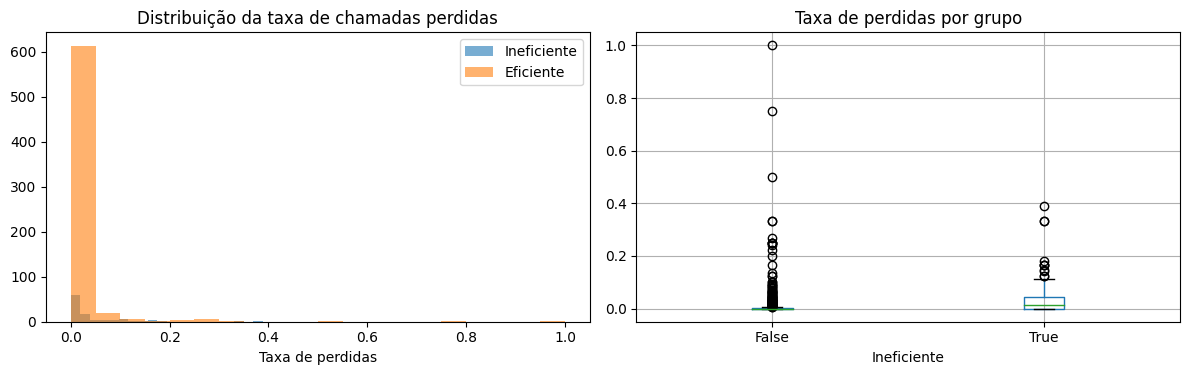

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma comparando as distribuições
dados_recebendo = operadores[operadores['atua_recebendo']]

axes[0].hist(dados_recebendo[dados_recebendo['ineficiente']]['taxa_perdidas'], bins=20, alpha=0.6, label='Ineficiente')
axes[0].hist(dados_recebendo[~dados_recebendo['ineficiente']]['taxa_perdidas'], bins=20, alpha=0.6, label='Eficiente')
axes[0].set_title('Distribuição da taxa de chamadas perdidas')
axes[0].set_xlabel('Taxa de perdidas')
axes[0].legend()

# Boxplot para ver medianas, quartis e outliers lado a lado
dados_recebendo.boxplot(column='taxa_perdidas', by='ineficiente', ax=axes[1])
axes[1].set_title('Taxa de perdidas por grupo')
axes[1].set_xlabel('Ineficiente')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Interpretação: taxa_perdidas por grupo

A distribuição geral é fortemente assimétrica à direita, com a maioria dos
operadores concentrada perto de zero e uma cauda longa de casos extremos —
confirmando que testes paramétricos (que assumem normalidade) não são
adequados aqui; usaremos Mann-Whitney U na Fase 3.

O boxplot mostra separação visual clara entre os grupos: operadores marcados
como ineficientes têm mediana de taxa_perdidas visivelmente maior que os
eficientes, com toda a distribuição deslocada para cima. Isso é uma evidência
preliminar (a confirmar estatisticamente) de que o critério de classificação
está capturando uma diferença real de comportamento, não ruído.

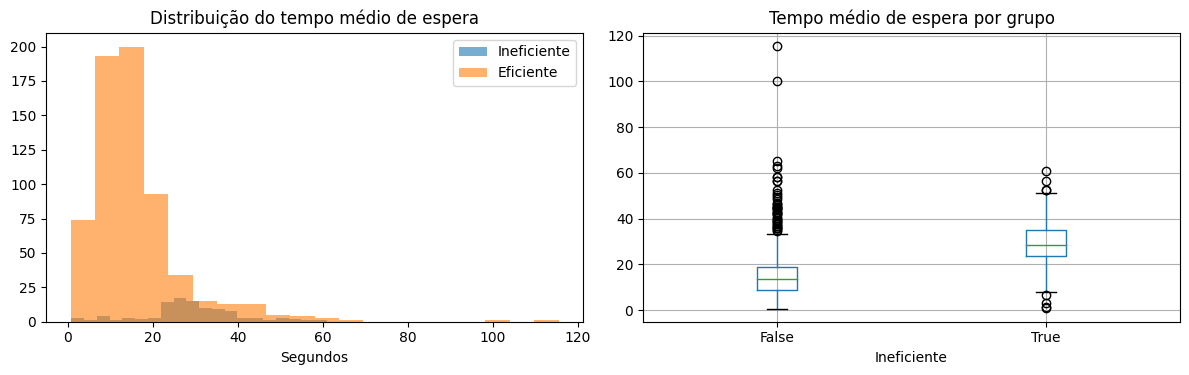

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dados_recebendo[dados_recebendo['ineficiente']]['wait_time_medio'], bins=20, alpha=0.6, label='Ineficiente')
axes[0].hist(dados_recebendo[~dados_recebendo['ineficiente']]['wait_time_medio'], bins=20, alpha=0.6, label='Eficiente')
axes[0].set_title('Distribuição do tempo médio de espera')
axes[0].set_xlabel('Segundos')
axes[0].legend()

dados_recebendo.boxplot(column='wait_time_medio', by='ineficiente', ax=axes[1])
axes[1].set_title('Tempo médio de espera por grupo')
axes[1].set_xlabel('Ineficiente')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Interpretação: wait_time_medio por grupo

Separação visual ainda mais clara que na métrica anterior: a mediana do grupo
ineficiente (~28s) é quase o dobro da mediana do grupo eficiente (~14s), com
sobreposição mínima entre as caixas. A distribuição segue não-normal (assimétrica
à direita), reforçando o uso de Mann-Whitney U na Fase 3.

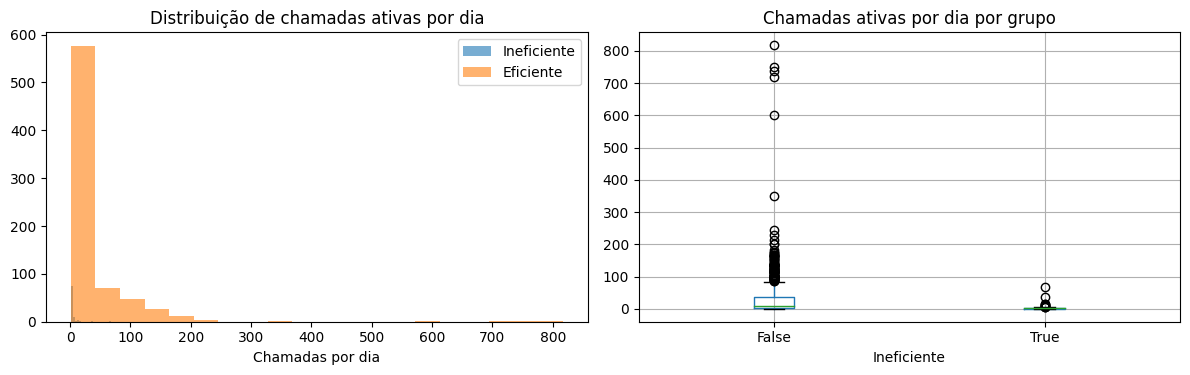

In [31]:
dados_saida = operadores[operadores['atua_saida']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dados_saida[dados_saida['ineficiente']]['chamadas_ativas_por_dia'], bins=20, alpha=0.6, label='Ineficiente')
axes[0].hist(dados_saida[~dados_saida['ineficiente']]['chamadas_ativas_por_dia'], bins=20, alpha=0.6, label='Eficiente')
axes[0].set_title('Distribuição de chamadas ativas por dia')
axes[0].set_xlabel('Chamadas por dia')
axes[0].legend()

dados_saida.boxplot(column='chamadas_ativas_por_dia', by='ineficiente', ax=axes[1])
axes[1].set_title('Chamadas ativas por dia por grupo')
axes[1].set_xlabel('Ineficiente')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Interpretação: chamadas_ativas_por_dia por grupo

Como esperado (métrica com direção inversa às anteriores), o grupo classificado
como ineficiente concentra valores baixos de chamadas ativas por dia, com a
caixa inteira próxima de zero — enquanto o grupo eficiente apresenta mediana
mais alta e maior variabilidade, incluindo operadores com volume bem acima da
média. A separação visual entre os grupos é clara, mas menos extrema que nas
métricas anteriores, dado o maior número de outliers no grupo eficiente.

<div style="background-color:#fdece8; padding:14px; border-left:6px solid #c62828;">

# 🧪 Fase 3 — Testando Hipóteses

Com o critério de ineficiência definido e as diferenças visuais já identificadas
na Fase 2, esta fase aplica **testes estatísticos formais** para confirmar se
as diferenças observadas entre operadores eficientes e ineficientes são
estatisticamente significativas, ou se podem ser explicadas por acaso.

**Hipóteses a testar (definidas na decomposição):**
- **H1** — Taxa de chamadas perdidas difere entre os grupos.
- **H2** — Tempo médio de espera difere entre os grupos.
- **H3** — Volume de chamadas ativas por dia difere entre os grupos.

Como vimos na Fase 2 que as três métricas têm distribuição não-normal
(assimétrica à direita, com caudas longas), usaremos o **teste de Mann-Whitney U**
— um teste não-paramétrico que compara as distribuições de dois grupos
independentes sem exigir premissa de normalidade.

</div>

### H1 — Taxa de chamadas perdidas

- **H0:** a distribuição da taxa de chamadas perdidas é igual entre operadores
  eficientes e ineficientes.
- **H1:** a distribuição da taxa de chamadas perdidas é diferente entre os grupos.
- **Teste:** Mann-Whitney U, nível de significância α = 0.05.

In [32]:
from scipy import stats

grupo_inef = dados_recebendo[dados_recebendo['ineficiente']]['taxa_perdidas']
grupo_ef = dados_recebendo[~dados_recebendo['ineficiente']]['taxa_perdidas']

stat, p_valor = stats.mannwhitneyu(grupo_inef, grupo_ef, alternative='two-sided')

print(f"Estatística U: {stat:.2f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.")
else:
    print("Não rejeitamos H0: não há evidência suficiente de diferença entre os grupos.")

Estatística U: 48290.50
p-valor: 0.000000
Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.


### Resultado H1

Com p-valor ≈ 0 (< 0.05), rejeitamos H0. Há diferença estatisticamente
significativa na taxa de chamadas perdidas entre operadores eficientes e
ineficientes, confirmando quantitativamente o padrão já observado na análise
visual da Fase 2.

### H2 — Tempo médio de espera

- **H0:** a distribuição do tempo médio de espera é igual entre operadores
  eficientes e ineficientes.
- **H1:** a distribuição do tempo médio de espera é diferente entre os grupos.
- **Teste:** Mann-Whitney U, nível de significância α = 0.05.

In [33]:
grupo_inef = dados_recebendo[dados_recebendo['ineficiente']]['wait_time_medio']
grupo_ef = dados_recebendo[~dados_recebendo['ineficiente']]['wait_time_medio']

stat, p_valor = stats.mannwhitneyu(grupo_inef, grupo_ef, alternative='two-sided')

print(f"Estatística U: {stat:.2f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.")
else:
    print("Não rejeitamos H0: não há evidência suficiente de diferença entre os grupos.")

Estatística U: 56482.50
p-valor: 0.000000
Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.


### Resultado H2

Com p-valor ≈ 0 (< 0.05), rejeitamos H0. Há diferença estatisticamente
significativa no tempo médio de espera entre operadores eficientes e
ineficientes, confirmando o padrão já observado visualmente na Fase 2.

### H3 — Volume de chamadas ativas por dia

- **H0:** a distribuição do volume de chamadas ativas por dia é igual entre
  operadores eficientes e ineficientes.
- **H1:** a distribuição do volume de chamadas ativas por dia é diferente
  entre os grupos.
- **Teste:** Mann-Whitney U, nível de significância α = 0.05.

Diferente de H1 e H2, aqui a expectativa de negócio é de direção oposta:
operadores ineficientes devem apresentar volume **menor**, não maior.

In [34]:
grupo_inef = dados_saida[dados_saida['ineficiente']]['chamadas_ativas_por_dia']
grupo_ef = dados_saida[~dados_saida['ineficiente']]['chamadas_ativas_por_dia']

stat, p_valor = stats.mannwhitneyu(grupo_inef, grupo_ef, alternative='two-sided')

print(f"Estatística U: {stat:.2f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.")
else:
    print("Não rejeitamos H0: não há evidência suficiente de diferença entre os grupos.")

Estatística U: 13142.50
p-valor: 0.000000
Rejeitamos H0: há diferença estatisticamente significativa entre os grupos.


### Resultado H3

Com p-valor ≈ 0 (< 0.05), rejeitamos H0. Há diferença estatisticamente
significativa no volume de chamadas ativas por dia entre operadores eficientes
e ineficientes, confirmando a direção esperada pelo negócio: operadores
ineficientes realizam significativamente menos chamadas ativas.

<div style="background-color:#fdece8; padding:10px; border-left:6px solid #c62828;">

### ✅ Conclusão da Fase 3

As três hipóteses (H1, H2, H3) foram confirmadas estatisticamente (p-valor ≈ 0
em todas), com Mann-Whitney U. Isso valida que o critério de classificação de
"operador ineficiente" (2 de 3 métricas no quartil de pior desempenho) captura
diferenças reais de comportamento, e não separações arbitrárias — as três
dimensões definidas pelo negócio (chamadas perdidas, tempo de espera, volume de
saída) realmente distinguem os dois grupos de forma consistente.

</div>

<div style="background-color:#fff8e1; padding:14px; border-left:6px solid #f9a825;">

# 📈 Fase 4 — Métricas de Negócio e Indicadores

Com os operadores classificados e as hipóteses validadas estatisticamente, esta
fase traduz os achados técnicos em **indicadores acionáveis para o negócio**:
quantos operadores ineficientes existem por cliente, se há concentração por
plano tarifário, e qual o impacto agregado desses operadores nas chamadas
perdidas totais. Também testamos aqui a hipótese complementar H4, definida na
decomposição, sobre a relação entre plano tarifário e ineficiência.

</div>

### Associando cada operador ao(s) cliente(s) e plano(s) tarifário(s)

Até agora, `operadores` é uma tabela agregada sem informação de cliente. Para
calcular indicadores de negócio (ex: "quantos operadores ineficientes por
cliente"), precisamos recuperar essa associação a partir da base original `df`.
Um operador pertence a um único cliente (`user_id`), então usamos o primeiro
valor encontrado por operador.

In [35]:
# Cada operator_id pertence a um único user_id/tariff_plan (checando isso antes de assumir)
operador_cliente = df_op.groupby('operator_id')[['user_id', 'tariff_plan']].nunique()

print("Operadores associados a mais de 1 user_id:", (operador_cliente['user_id'] > 1).sum())
print("Operadores associados a mais de 1 tariff_plan:", (operador_cliente['tariff_plan'] > 1).sum())

Operadores associados a mais de 1 user_id: 0
Operadores associados a mais de 1 tariff_plan: 0


Confirmado: nenhum operador está associado a mais de um cliente ou plano
tarifário, validando que podemos trazer essa informação diretamente para a
tabela `operadores` sem risco de ambiguidade.

In [36]:
mapa_cliente = df_op.groupby('operator_id')[['user_id', 'tariff_plan']].first()

operadores = operadores.merge(mapa_cliente, on='operator_id', how='left')

print(operadores[['user_id', 'tariff_plan', 'ineficiente']].isnull().sum())
operadores.head()

user_id        0
tariff_plan    0
ineficiente    0
dtype: int64


,operator_id,total_chamadas_recebidas,total_perdidas,wait_time_medio,taxa_perdidas,total_chamadas_saida,dias_ativos,chamadas_ativas_por_dia,atua_recebendo,atua_saida,criterio_perdidas,criterio_espera,criterio_saida,qtd_criterios_ruins,ineficiente,user_id,tariff_plan
0,879896.0,58.0,0.0,13.396199,0.0,816.0,48.0,17.000000,True,True,False,False,False,0,False,166406,B
1,879898.0,104.0,0.0,14.080117,0.0,7191.0,79.0,91.025316,True,True,False,False,False,0,False,166406,B
2,880020.0,7.0,0.0,7.714286,0.0,34.0,7.0,4.857143,True,True,False,False,False,0,False,166377,B
3,880022.0,8.0,0.0,14.000000,0.0,174.0,36.0,4.833333,True,True,False,False,False,0,False,166377,B
4,880026.0,24.0,0.0,5.935185,0.0,2188.0,77.0,28.415584,True,True,False,False,False,0,False,166377,B


### Quantos operadores ineficientes cada cliente tem

Este é o indicador mais diretamente acionável para o negócio: para cada
cliente (empresa que usa a CallMeMaybe), quantos operadores foram classificados
como ineficientes, e qual a proporção sobre o total de operadores daquele
cliente. Isso permite priorizar quais clientes precisam de atenção/intervenção
mais urgente.

In [37]:

por_cliente = operadores.groupby('user_id').agg(
    total_operadores=('operator_id', 'count'),
    operadores_ineficientes=('ineficiente', 'sum')
)

por_cliente['proporcao_ineficientes'] = (
    por_cliente['operadores_ineficientes'] / por_cliente['total_operadores']
)

por_cliente.sort_values(by='proporcao_ineficientes', ascending=False).head(10)

,total_operadores,operadores_ineficientes,proporcao_ineficientes
user_id,,,
168004,1,1,1.0
167543,1,1,1.0
168155,2,2,1.0
166619,1,1,1.0
167200,1,1,1.0
167264,2,2,1.0
167621,1,1,1.0
166958,1,1,1.0
166669,1,1,1.0


In [38]:
# Focando em clientes com pelo menos 3 operadores, onde a proporção é mais confiável
clientes_relevantes = por_cliente[por_cliente['total_operadores'] >= 3]

clientes_relevantes.sort_values(by='proporcao_ineficientes', ascending=False).head(10)

,total_operadores,operadores_ineficientes,proporcao_ineficientes
user_id,,,
167977,5,5,1.000000
166604,3,2,0.666667
166800,5,3,0.600000
166407,7,4,0.571429
166916,14,7,0.500000
166541,4,2,0.500000
167059,7,3,0.428571
166503,5,2,0.400000
167715,3,1,0.333333


### Ranking de priorização por cliente

Ao filtrar clientes com pelo menos 3 operadores, o ranking se torna mais
confiável para ação de negócio. O cliente 167977 lidera com 100% dos operadores
classificados como ineficientes (5 de 5), mas o caso do cliente 166916 merece
atenção especial: com 14 operadores, 7 (50%) foram classificados como
ineficientes — um volume grande o suficiente para indicar um problema
estrutural na operação desse cliente, não apenas casos isolados.

### H4 — Plano tarifário e proporção de operadores ineficientes

- **H0:** a proporção de operadores ineficientes é igual entre os planos
  tarifários.
- **H1:** existe associação entre plano tarifário e classificação de
  ineficiência.
- **Teste:** qui-quadrado de independência (chi-square), já que estamos
  comparando duas variáveis categóricas (`tariff_plan` e `ineficiente`).

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

A quarta hipótese é a mais interessante, porque sai do operador e vai para o **cliente**: verificar se o plano tarifário se relaciona com a proporção de operadores ineficientes. Isso conecta a análise operacional a uma questão comercial, que é o tipo de ponte que a direção valoriza.
</div>

In [39]:
tabela_contingencia = pd.crosstab(operadores['tariff_plan'], operadores['ineficiente'])
print(tabela_contingencia)
print()

chi2, p_valor, dof, esperado = stats.chi2_contingency(tabela_contingencia)

print(f"Qui-quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Graus de liberdade: {dof}")

if p_valor < 0.05:
    print("Rejeitamos H0: existe associação entre plano tarifário e ineficiência.")
else:
    print("Não rejeitamos H0: não há evidência de associação entre plano tarifário e ineficiência.")

ineficiente  False  True 
tariff_plan              
A              274     28
B              342     44
C              342     32

Qui-quadrado: 1.8676
p-valor: 0.393057
Graus de liberdade: 2
Não rejeitamos H0: não há evidência de associação entre plano tarifário e ineficiência.


### Resultado H4

Com p-valor = 0,393 (> 0.05), **não rejeitamos H0**. Não há evidência
estatística de associação entre plano tarifário e a proporção de operadores
classificados como ineficientes — a distribuição é praticamente proporcional
nos três planos (A: ~9,3%, B: ~11,4%, C: ~8,6% de ineficientes).

Esse é um resultado relevante para o negócio: indica que a causa da
ineficiência **não está relacionada ao tipo de plano contratado pelo cliente**,
sugerindo que fatores como gestão local, treinamento ou carga de trabalho
específica de cada operação são explicações mais prováveis do que o plano em
si — um caminho de investigação para além do escopo destes dados.

<div style="background-color:#fff8e1; padding:10px; border-left:6px solid #f9a825;">

### ✅ Conclusão da Fase 4

Consolidamos os achados técnicos em indicadores de negócio: identificamos os
clientes prioritários para intervenção (destaque para o cliente 166916, com
50% dos operadores ineficientes em uma base de 14), e testamos H4, descartando
o plano tarifário como fator explicativo da ineficiência. Isso direciona a
recomendação de negócio para ações operacionais (treinamento, supervisão,
redistribuição de carga) em vez de mudanças comerciais.

</div>

## Conclusão

Nesse projeto eu analisei os dados de ligações da CallMeMaybe pra tentar entender quais operadores estão com desempenho ruim, seguindo os 3 critérios que a empresa pediu: muitas ligações perdidas, tempo de espera alto e (pra quem faz ligação de saída) poucas ligações ativas.

Primeiro eu limpei os dados: tirei quase 4900 linhas duplicadas, arrumei os tipos de data, e decidi o que fazer com os valores que estavam faltando (por exemplo, `operator_id` vazio geralmente era ligação que ninguém atendeu, então não dava pra simplesmente apagar essas linhas).

Depois eu montei uma tabela com uma linha por operador, calculando as 3 métricas, e usei percentil (os 25% piores em cada métrica) pra decidir quem é "ineficiente". Pra não punir alguém injustamente por causa de um dia ruim isolado, só considerei ineficiente quem caiu no critério ruim em pelo menos 2 das 3 métricas. No fim, deu 104 operadores (quase 10% do total).

Fazendo os gráficos, já dava pra ver que os dois grupos (eficiente x ineficiente) eram bem diferentes um do outro nas 3 métricas. E quando testei estatisticamente (teste de Mann-Whitney, porque os dados não seguem uma distribuição normal), confirmei que sim, a diferença é real e não é coincidência — nas 3 hipóteses (H1, H2, H3) o p-valor deu praticamente 0.

Também testei se o plano tarifário do cliente (A, B ou C) tinha alguma relação com a quantidade de operadores ineficientes, e aqui o resultado foi diferente: não deu diferença significativa (p-valor de 0,39). Ou seja, não é o plano que explica o problema — é mais provável que seja algo de gestão/treinamento em cada empresa cliente.

Por fim, olhando por cliente, dá pra ver quem precisa de atenção mais urgente. Um exemplo que chamou atenção foi o cliente 166916: de 14 operadores, 7 (metade) foram classificados como ineficientes — isso não parece coisa isolada, parece um problema mais estrutural naquela operação.

**No geral**, o critério que criei pra medir "ineficiência" funcionou bem: as diferenças que eu vi nos gráficos se confirmaram nos testes estatísticos, e consegui gerar uma informação prática — uma lista de clientes/operadores que precisam de atenção — que é exatamente o que a CallMeMaybe pediu no início do projeto.

In [40]:
# Exportando a tabela de operadores (nível de análise principal do dashboard)
operadores.to_csv('operadores_analise.csv', index=False)

# Exportando a tabela agregada por cliente (para visão gerencial)
por_cliente_export = por_cliente.reset_index()
por_cliente_export.to_csv('clientes_analise.csv', index=False)

print("Arquivos exportados com sucesso.")
print("operadores_analise.csv:", operadores.shape)
print("clientes_analise.csv:", por_cliente_export.shape)

Arquivos exportados com sucesso.
operadores_analise.csv: (1062, 17)
clientes_analise.csv: (290, 4)


### Refatorando: função para comparar métricas entre grupos

Ao longo da Fase 2, repetimos praticamente o mesmo código 3 vezes (uma vez por
métrica) para gerar histograma + boxplot comparando eficientes vs. ineficientes.
Isso viola o princípio de não repetir código para ações que se repetem — vamos
transformar essa lógica em uma função reutilizável, documentada com docstring.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Ótimo fechamento técnico: identificar que você estava repetindo o mesmo bloco várias vezes e **refatorar em uma função**. Esse instinto de eliminar repetição é exatamente o que se espera de quem vai trabalhar com código em equipe.
</div>

In [41]:
def comparar_metrica_por_grupo(dados, coluna_metrica, titulo_metrica, unidade=''):
    """Gera histograma e boxplot comparando uma métrica entre operadores
    eficientes e ineficientes.

    Esta função automatiza a visualização usada repetidamente na Fase 2 (EDA)
    para comparar a distribuição de uma métrica numérica entre os dois grupos
    de classificação de eficiência, facilitando tanto a inspeção visual da
    diferença entre grupos quanto a avaliação da forma da distribuição
    (normal ou assimétrica), que orienta a escolha do teste estatístico.

    Parameters
    ----------
    dados : pandas.DataFrame
        DataFrame já filtrado para a população relevante (ex: apenas
        operadores que atuam recebendo chamadas), contendo as colunas
        `coluna_metrica` e `ineficiente`.
    coluna_metrica : str
        Nome da coluna numérica a ser comparada entre os grupos.
    titulo_metrica : str
        Nome legível da métrica, usado nos títulos dos gráficos.
    unidade : str, opcional
        Unidade de medida da métrica (ex: 'segundos'), usada no rótulo do
        eixo x do histograma.

    Returns
    -------
    None
        A função apenas exibe os gráficos; não retorna nenhum valor.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    grupo_inef = dados[dados['ineficiente']][coluna_metrica]
    grupo_ef = dados[~dados['ineficiente']][coluna_metrica]

    axes[0].hist(grupo_inef, bins=20, alpha=0.6, label='Ineficiente')
    axes[0].hist(grupo_ef, bins=20, alpha=0.6, label='Eficiente')
    axes[0].set_title(f'Distribuição de {titulo_metrica}')
    axes[0].set_xlabel(unidade if unidade else titulo_metrica)
    axes[0].legend()

    dados.boxplot(column=coluna_metrica, by='ineficiente', ax=axes[1])
    axes[1].set_title(f'{titulo_metrica} por grupo')
    axes[1].set_xlabel('Ineficiente')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()

### Reaproveitando o código anterior com a função

Agora `comparar_metrica_por_grupo`, substituímos os três blocos de
código repetidos (histograma + boxplot para cada métrica) por chamadas simples
da função — o resultado visual é o mesmo já analisado anteriormente, mas o
código fica mais limpo e sem repetição.

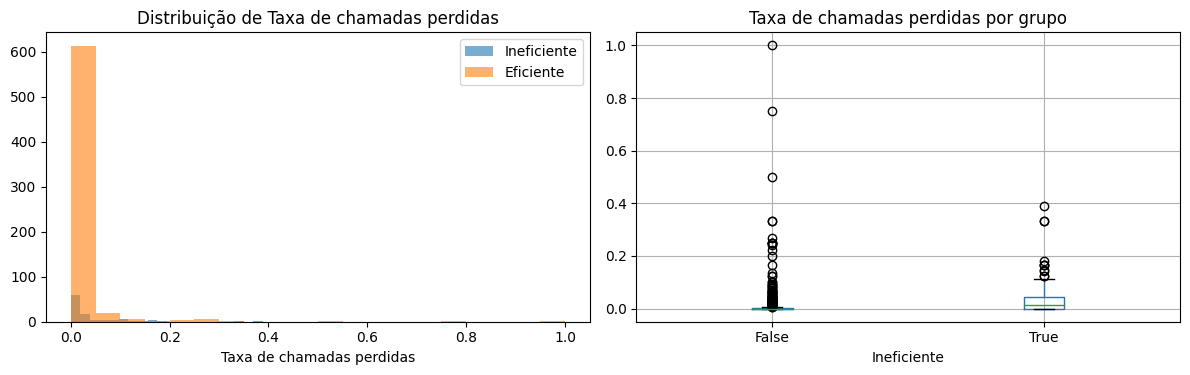

In [42]:
comparar_metrica_por_grupo(dados_recebendo, 'taxa_perdidas', 'Taxa de chamadas perdidas')

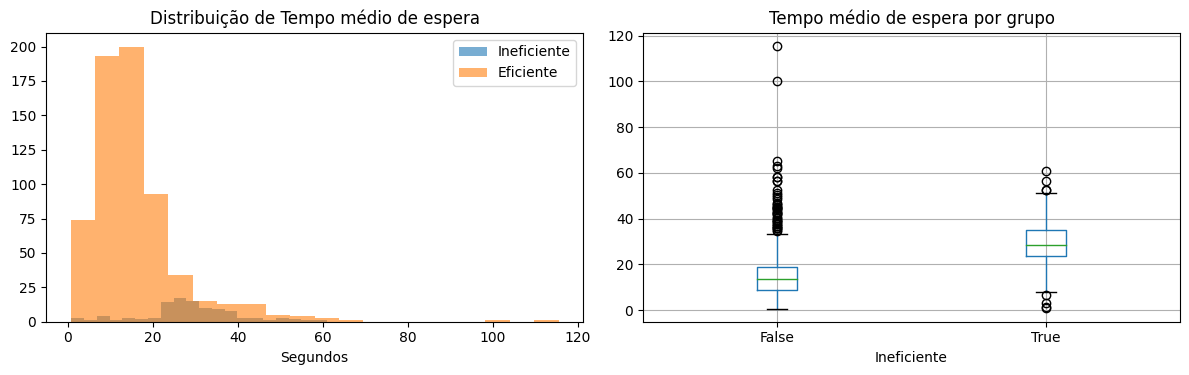

In [43]:
comparar_metrica_por_grupo(dados_recebendo, 'wait_time_medio', 'Tempo médio de espera', unidade='Segundos')

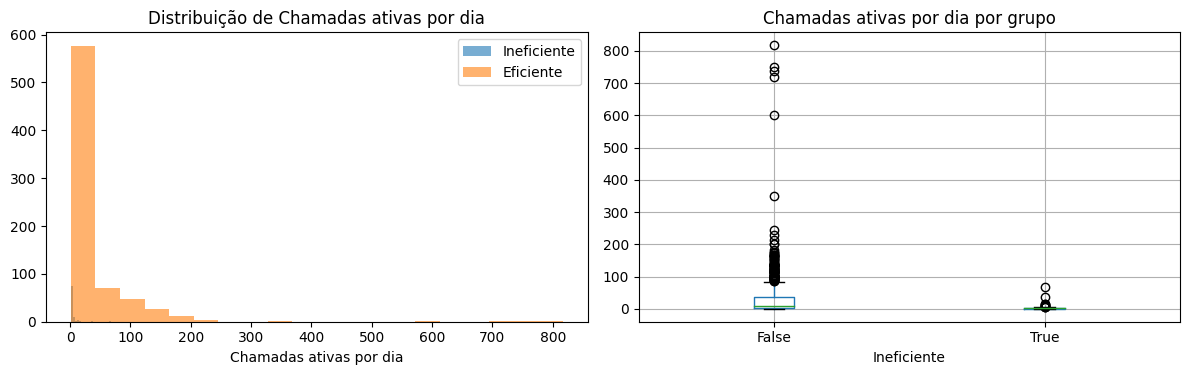

In [44]:
comparar_metrica_por_grupo(dados_saida, 'chamadas_ativas_por_dia', 'Chamadas ativas por dia')

## Links do Projeto

- **Dashboard (Tableau Public):** [CallMeMaybe — Análise de Operadores Ineficientes](https://public.tableau.com/app/profile/murilo.lima.dos.santos/viz/ProjetofinalTripleten_17869971030720/Dashboard?publish=yes)

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Testei o link do **dashboard no Tableau Public** e ele abre normalmente. Publicar o painel junto da análise fecha o ciclo: quem não vai ler o notebook consegue explorar os resultados sozinho. Parabéns pela aprovação!
</div>